In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import os
import copy
import re
import matplotlib.cm as cm
import matplotlib as mpl


In [3]:
##Common functions
mpl.rcParams.update({
    "font.size": 16,             # base font
    "axes.labelsize": 18,        # x/y label
    "axes.titlesize": 20,        # axes/plot title
    "xtick.labelsize": 12,       # tick labels
    "ytick.labelsize": 12,
    "legend.fontsize": 14,       # legend entries
    "legend.title_fontsize": 15  # legend title
})

def ret_config(config_path, key):
    with open(config_path, "r") as file:
        for line in file:
            if line.startswith(key + ":"):
                return line.split(":")[1].strip()  # Get the value after ':' and remove spaces
    return None  # Return None if the key is not found
def get_data_from_experiment_oracle_perr(exp_path): #Gets the data to compare oracle p_errs!
    df=pd.read_csv(exp_path+'/ErrVsEpochs.csv')
    df_numpy=df.to_numpy()
    x=df_numpy[:,0]; y=df_numpy[:,1];  y_err=df_numpy[:,2]/2
    p_err=ret_config(exp_path+"/RunConfig.txt","Oracle Perr")
    return x,y,y_err,p_err

def get_data_from_experiment_oracle_perr(exp_path): #Gets the data to compare oracle p_errs!
    df=pd.read_csv(exp_path+'/ErrVsEpochs.csv')
    df_numpy=df.to_numpy()
    x=df_numpy[:,0]; y=df_numpy[:,1];  y_err=df_numpy[:,2]/2
    p_err=ret_config(exp_path+"/RunConfig.txt","Oracle Perr")
    return x,y,y_err,p_err

def get_data_from_experiment_oracle_subset(exp_path):
    df=pd.read_csv(exp_path+'/ErrVsEpochs.csv')
    df_numpy=df.to_numpy()
    x=df_numpy[:,0]; y=df_numpy[:,1];  y_err=df_numpy[:,2]/2
    n_subset=ret_config(exp_path+"/RunConfig.txt","NsubsetCV")
    if int(n_subset)==0:
        n_subset=ret_config(exp_path+"/RunConfig.txt","NtotalReads") #If it was zero, probably it was a run with all reads, no subset.
    return x,y,y_err,n_subset

def get_eq_guess(n_prot,n_dists_est=1000):
    exponential_vars = np.random.exponential(size=(n_dists_est, n_prot))
    random_dists = exponential_vars / exponential_vars.sum(axis=1, keepdims=True)
    equidis_err = np.mean(np.mean(np.abs(random_dists-np.ones(shape=(n_dists_est,n_prot))/n_prot),axis=1))
    return equidis_err

def eng_notation(num):
    if num >= 1e9:
        return f"{num/1e9:.3g}B"  # Billion
    elif num >= 1e6:
        return f"{num/1e6:.3g}M"  # Million
    elif num >= 1e3:
        return f"{num/1e3:.3g}K"  # Thousand
    else:
        return str(num)  # No conversion for small numbers

def compare_oracle_dif_errs(n_prot, log=True, results_path="../results/"):
    out_path = f"{results_path}/{n_prot}_Prot/Oracle_dif_errs/"
    plt.figure(dpi=600)
    plt.ylabel("MAE")
    plt.xlabel("N Epochs")
    xs, ys, y_errs, p_errs = [], [], [], []

    with os.scandir(out_path) as entries:
        for entry in entries:
            if entry.is_dir() and re.match(r"^\d", entry.name):
                x, y, y_err, p_err = get_data_from_experiment_oracle_perr(os.path.join(out_path, entry.name))
                xs.append(x); ys.append(y); y_errs.append(y_err); p_errs.append(float(p_err))

    sorted_data = sorted(zip(p_errs, xs, ys, y_errs), key=lambda t: t[0])
    p_errs, xs, ys, y_errs = zip(*sorted_data)
    
    colors = cm.Blues(np.flip(np.linspace(0.4, 0.9, len(xs))))
    for x, y, y_err, p_err, color in zip(xs, ys, y_errs, p_errs, colors):
        plt.errorbar(x, y, yerr=y_err, label=f"e = {p_err}", color=color,fmt='o',
                        linestyle='dashed',
                        elinewidth=1,
                        capthick=1,
                        capsize=3  )

    equidis_err = get_eq_guess(n_prot)
    plt.axhline(y=equidis_err, color='red', linestyle='dotted', label=f'Uniform guess (Err = {equidis_err:.2g}'+")")

    plt.legend(title="Oracle error e")
    #plt.title("Oracle Perr Comparison")
    if log:
        plt.yscale('log')
    plt.grid(visible=True, which='major', linewidth=1.5)
    plt.grid(visible=True, which='minor', linewidth=0.5, linestyle='-')
    plt.xlim([0, np.max(xs)+1])
    plt.tight_layout()
    plt.savefig(f"{results_path}/{n_prot}_Prot/OraclePerr.png")
    plt.show()

def compare_oracle_subsets_final_value(n_prot, log=True, subfolder="Oracle_subsets/", results_path="../results/"):    
    plt.figure(dpi=600)
    plt.ylabel("MAE")
    plt.xlabel("Number of reads")
    ys, y_errs, n_subsets = [], [], []
    out_path = f"{results_path}/{n_prot}_Prot/{subfolder}"

    with os.scandir(out_path) as entries:
        for entry in entries:
            if entry.is_dir() and re.match(r"^\d", entry.name):
                x, y, y_err, n_subset = get_data_from_experiment_oracle_subset(os.path.join(out_path, entry.name))
                ys.append(y[-1]); y_errs.append(y_err[-1]); n_subsets.append(float(n_subset))

    subset_indexes = np.argsort(n_subsets)
    n_subsets = np.asarray(n_subsets); ys = np.asarray(ys); y_errs = np.asarray(y_errs)
    colors = cm.Blues(np.linspace(0.4, 0.9, len(n_subsets)))
    

    plt.errorbar(n_subsets[subset_indexes], ys[subset_indexes], yerr=y_errs[subset_indexes],
                color=colors[-1], label="Oracle",fmt='o',
                        linestyle='dashed',
                        elinewidth=1,
                        capthick=1,
                        capsize=3  )

    equidis_err = get_eq_guess(n_prot)
    plt.axhline(y=equidis_err, color='red', linestyle='dotted', label=f'Uniform guess (Err = {equidis_err:.3g}' + ")")

    plt.legend(title="Method")
    #plt.title("Final MAE vs. Reads")
    if log:
        plt.xscale('log')
        plt.yscale('log')

    plt.grid(visible=True, which='major', linewidth=1.5)
    plt.grid(visible=True, which='minor', linewidth=0.5, linestyle='-')
    plt.tight_layout()
    plt.savefig(f"{results_path}/{n_prot}_Prot/OracleSubsets1.png")
    plt.show()

def compare_oracle_subsets(n_prot, log=True, subfolder="Oracle_subsets/", results_path="../results/"):
    out_path = f"{results_path}/{n_prot}_Prot/{subfolder}"
    plt.figure(dpi=600)
    plt.ylabel("MAE")
    plt.xlabel("N Epochs")
    xs, ys, y_errs, n_subsets = [], [], [], []

    with os.scandir(out_path) as entries:
        for entry in entries:
            if entry.is_dir() and re.match(r"^\d", entry.name):
                x, y, y_err, n_subset = get_data_from_experiment_oracle_subset(os.path.join(out_path, entry.name))
                xs.append(x); ys.append(y); y_errs.append(y_err); n_subsets.append(float(n_subset))

    sorted_data = sorted(zip(n_subsets, xs, ys, y_errs), key=lambda t: t[0])
    n_subsets, xs, ys, y_errs = zip(*sorted_data)
    colors = cm.Blues(np.linspace(0.4, 0.9, len(xs)))

    for x, y, y_err, n_subset, color in zip(xs, ys, y_errs, n_subsets, colors):
        plt.errorbar(x, y, yerr=y_err,
                     label=f"{eng_notation(n_subset)} samples", color=color,fmt='o',
                        linestyle='dashed',
                        elinewidth=1,
                        capthick=1,
                        capsize=3  )

    equidis_err = get_eq_guess(n_prot)
    plt.axhline(y=equidis_err, color='red', linestyle='dotted', label=f'Uniform guess (Err = {equidis_err:.2g}'+")")

    plt.legend(title="Subset Size")
    #plt.title("MAE vs Epochs (Subsets)")
    if log:
        plt.yscale('log')
    plt.grid(visible=True, which='major', linewidth=1.5)
    plt.grid(visible=True, which='minor', linewidth=0.5, linestyle='-')
    plt.xlim([0, np.max(xs)+1])
    plt.tight_layout()
    plt.savefig(f"{results_path}/{n_prot}_Prot/OracleSubsets2.png")
    plt.show()

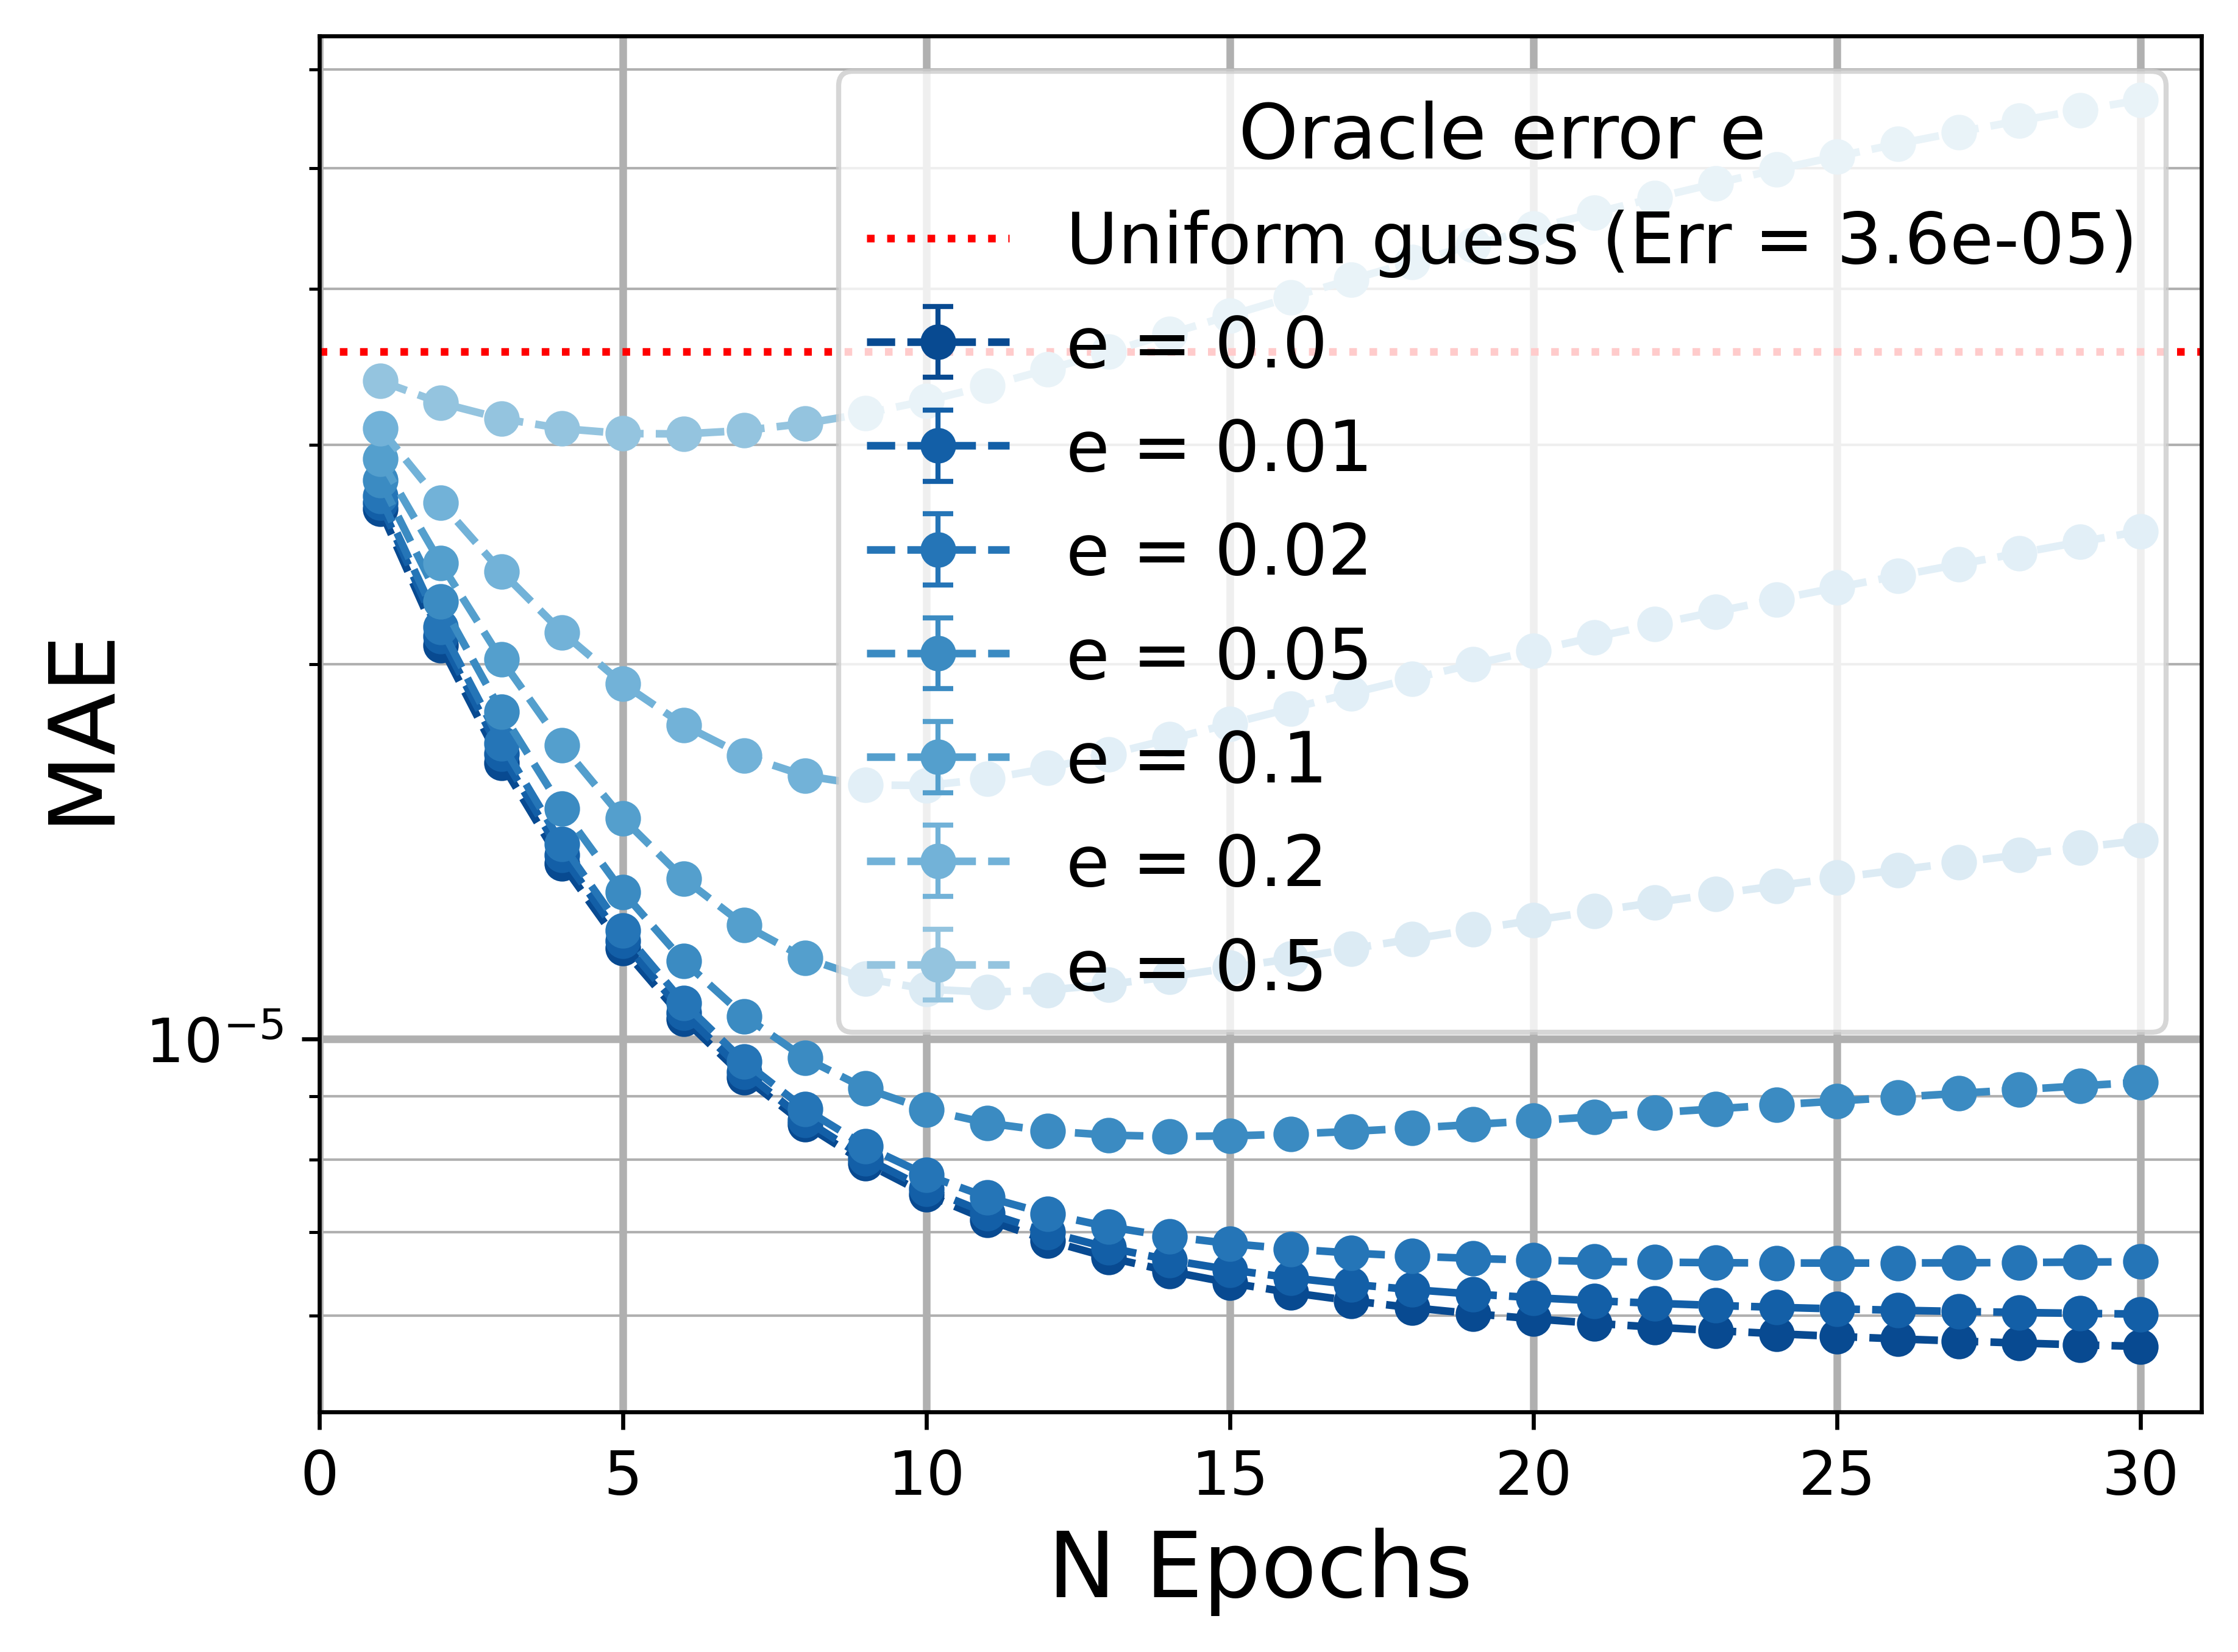

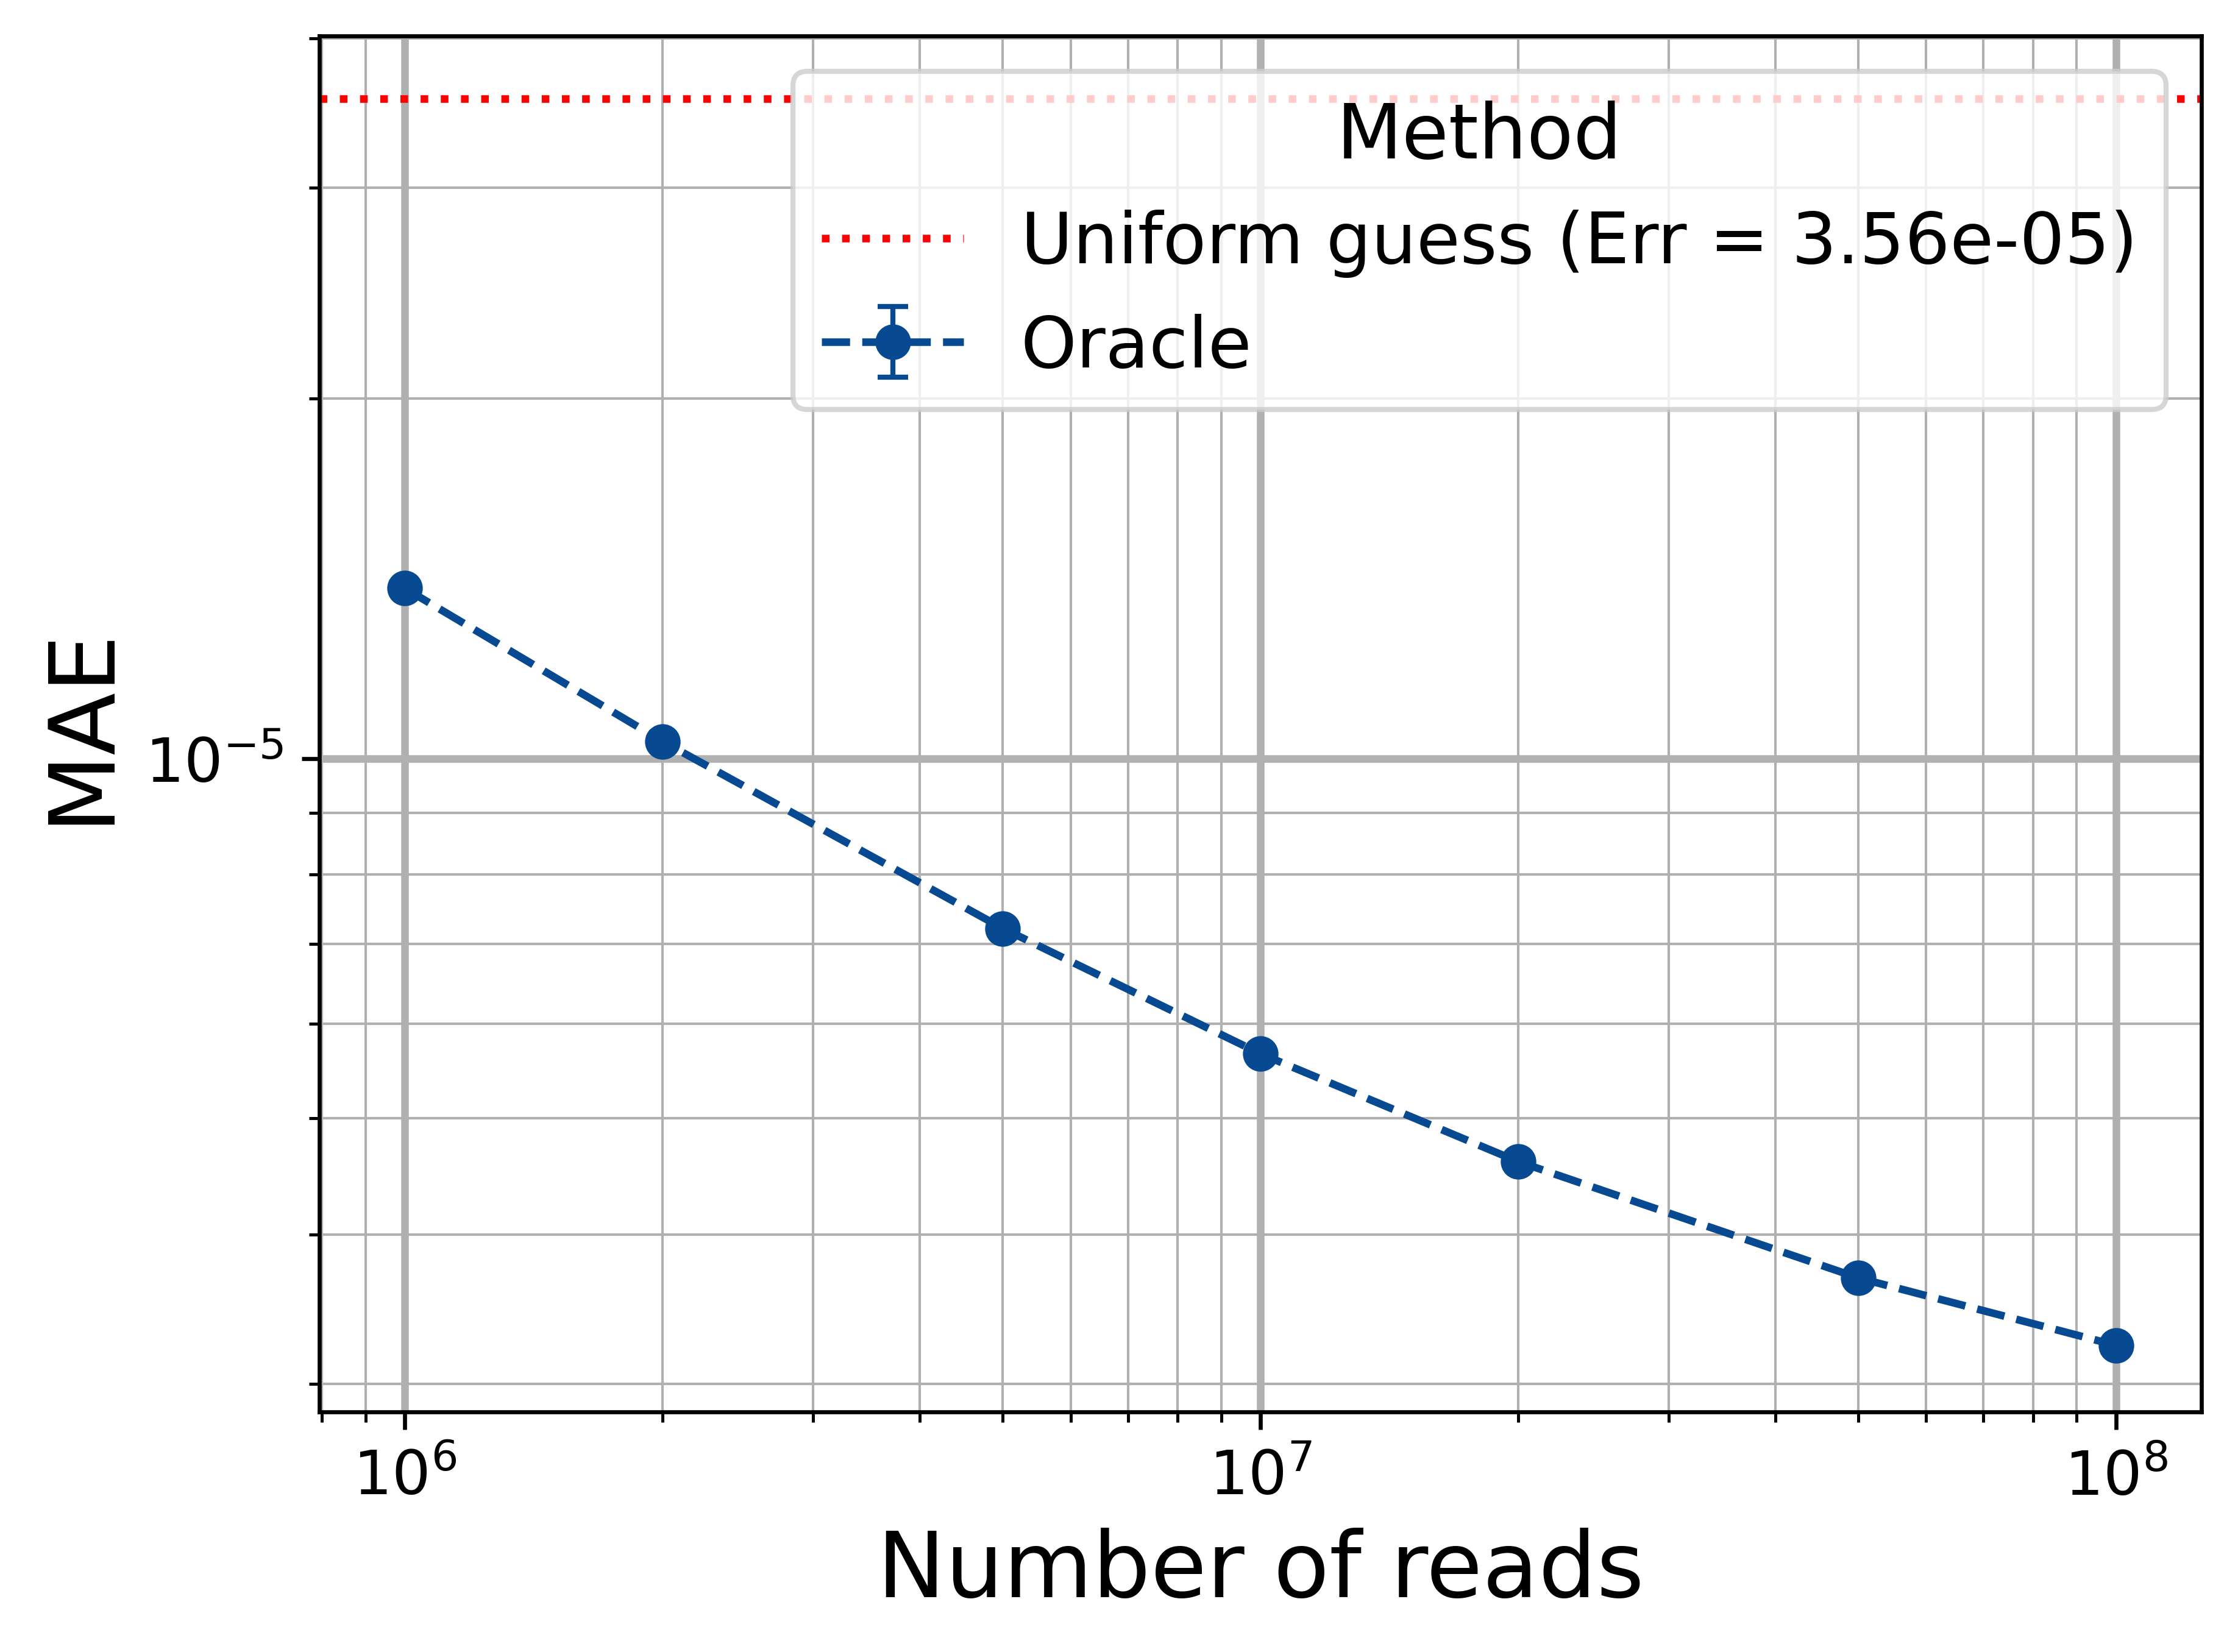

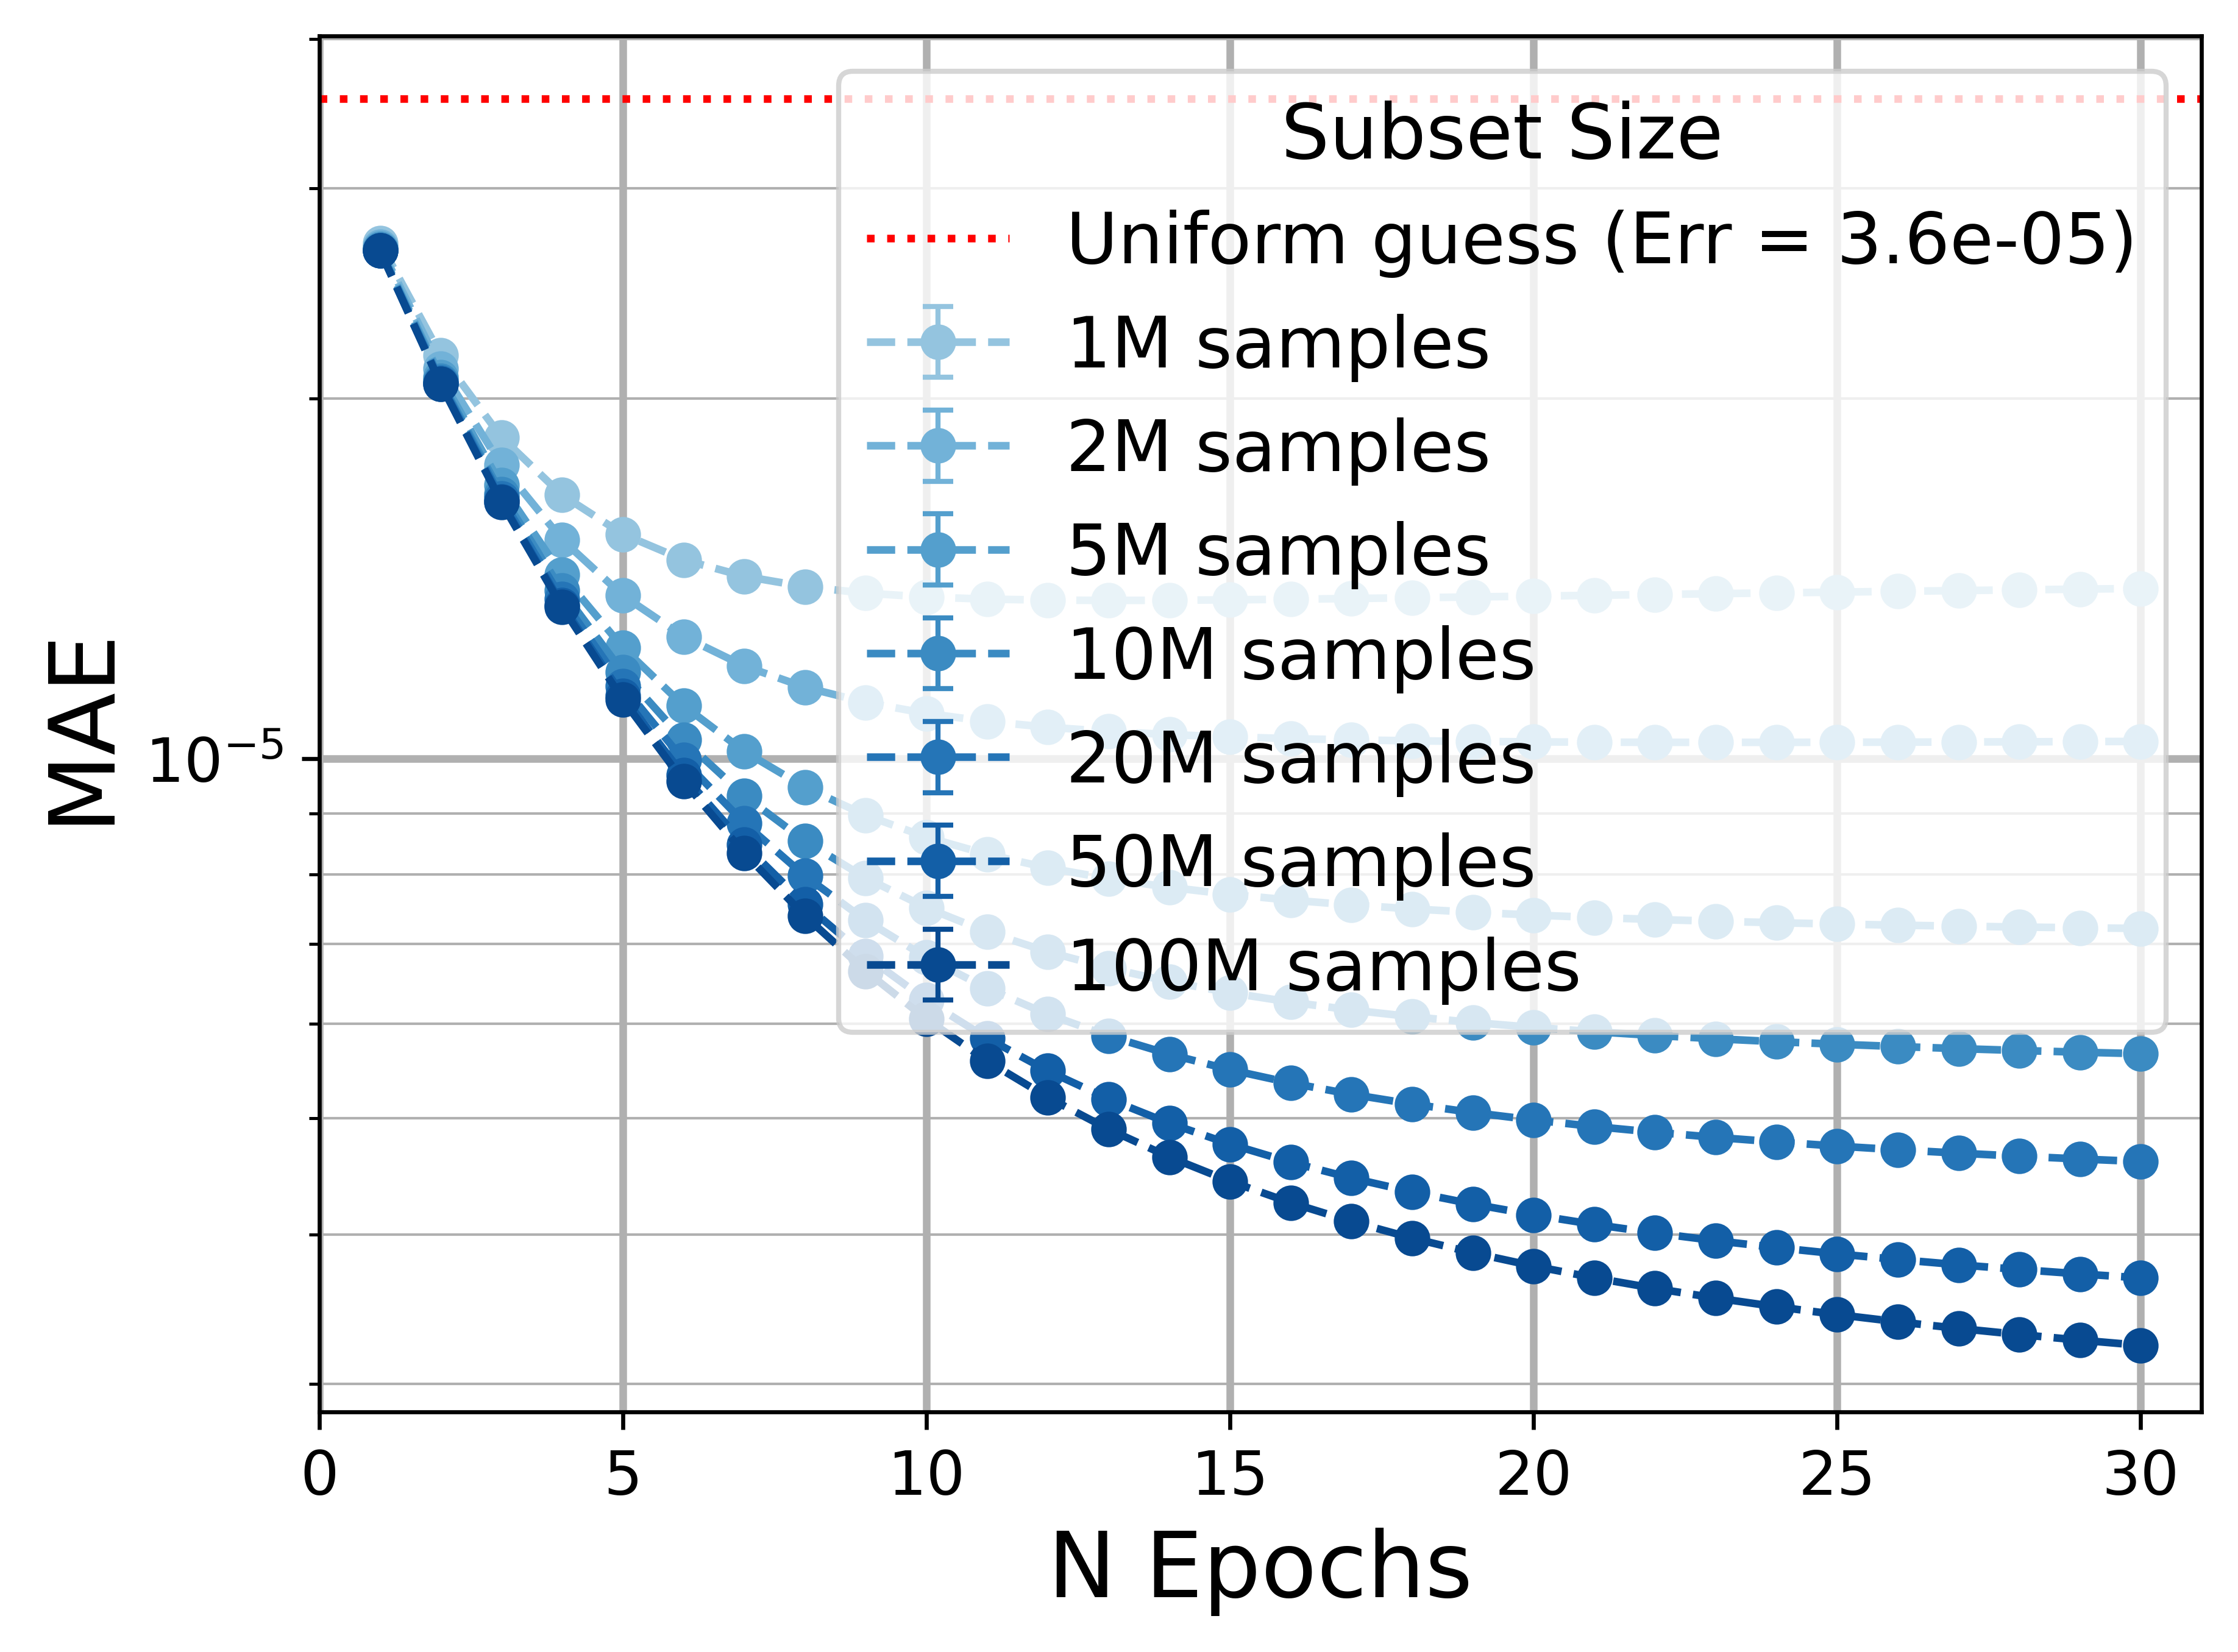

In [4]:
compare_oracle_dif_errs(20642)
compare_oracle_subsets_final_value(20642)
compare_oracle_subsets(20642)

In [5]:
path_probeam_better_config="/home/jkipen/ProtInfGPU/results/20642_Prot/ProbeamBetterConfigW100/NSpar1000Run/"
path_probeam="/home/jkipen/ProtInfGPU/results/20642_Prot/ProbeamW100/NSpar1000Run/"
path_oracle="/home/jkipen/ProtInfGPU/results/20642_Prot/ProbeamBetterConfigW100/Oracle/"

def get_relevant_data_exp(exp_path):
    df=pd.read_csv(exp_path+'/ErrVsEpochs.csv')
    df_numpy=df.to_numpy()
    x=df_numpy[:,0]; y=df_numpy[:,1];  y_err=df_numpy[:,2]/2
    runtime_s=int(ret_config(exp_path+"/RunConfig.txt","Runtime"))
    return x,y,y_err,runtime_s

def plot_comparison_error(path_probeam,path_probeam_better,path_oracle,log=True):
    plt.figure(dpi=600)
    plt.ylabel("MAE")
    plt.xlabel("N Epochs")
    
    x_p,y_p,y_err_p,runtime_s_p=get_relevant_data_exp(path_probeam)
    x_pb,y_pb,y_err_pb,runtime_s_pb=get_relevant_data_exp(path_probeam_better)
    x_o,y_o,y_err_o,runtime_s_o=get_relevant_data_exp(path_oracle)
    
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    #We divide by 3600 so it is hours, and /10 to get each run (it was ten runs).
    plt.errorbar(x_o, y_o, yerr=y_err_o, color=colors[0],label="Oracle ("+"{:.1f}".format(runtime_s_o/36000)+"h)"
                ,fmt='o',linestyle='dashed',elinewidth=1,capthick=1,capsize=3)
    plt.errorbar(x_p, y_p, yerr=y_err_p, color=colors[1],label="Probeam ("+"{:.1f}".format(runtime_s_p/36000)+"h)"
                 ,fmt='o',linestyle='dashed',elinewidth=1,capthick=1,capsize=3)
    plt.errorbar(x_pb, y_pb, yerr=y_err_pb, color=colors[2],label="Probeam better rates ("+"{:.1f}".format(runtime_s_pb/36000)+"h)"
                 ,fmt='o',linestyle='dashed',elinewidth=1,capthick=1,capsize=3)
    

    equidis_err=get_eq_guess(20642);
    plt.axhline(y=equidis_err, color='red', linestyle='dotted', label=f'Uniform guess (Err = {equidis_err:.2g})')

    plt.legend(title= "Method")
    if log:
        plt.yscale('log')
    plt.grid(visible=True, which='major', linewidth=1.5)
    plt.grid(visible=True, which='minor', linewidth=0.5, linestyle='-')
    #plt.xlim([0, np.max(x_o)])
    plt.tight_layout()
    plt.savefig(f"../results/20642_Prot/ComparisonMethods.png")
    plt.show()

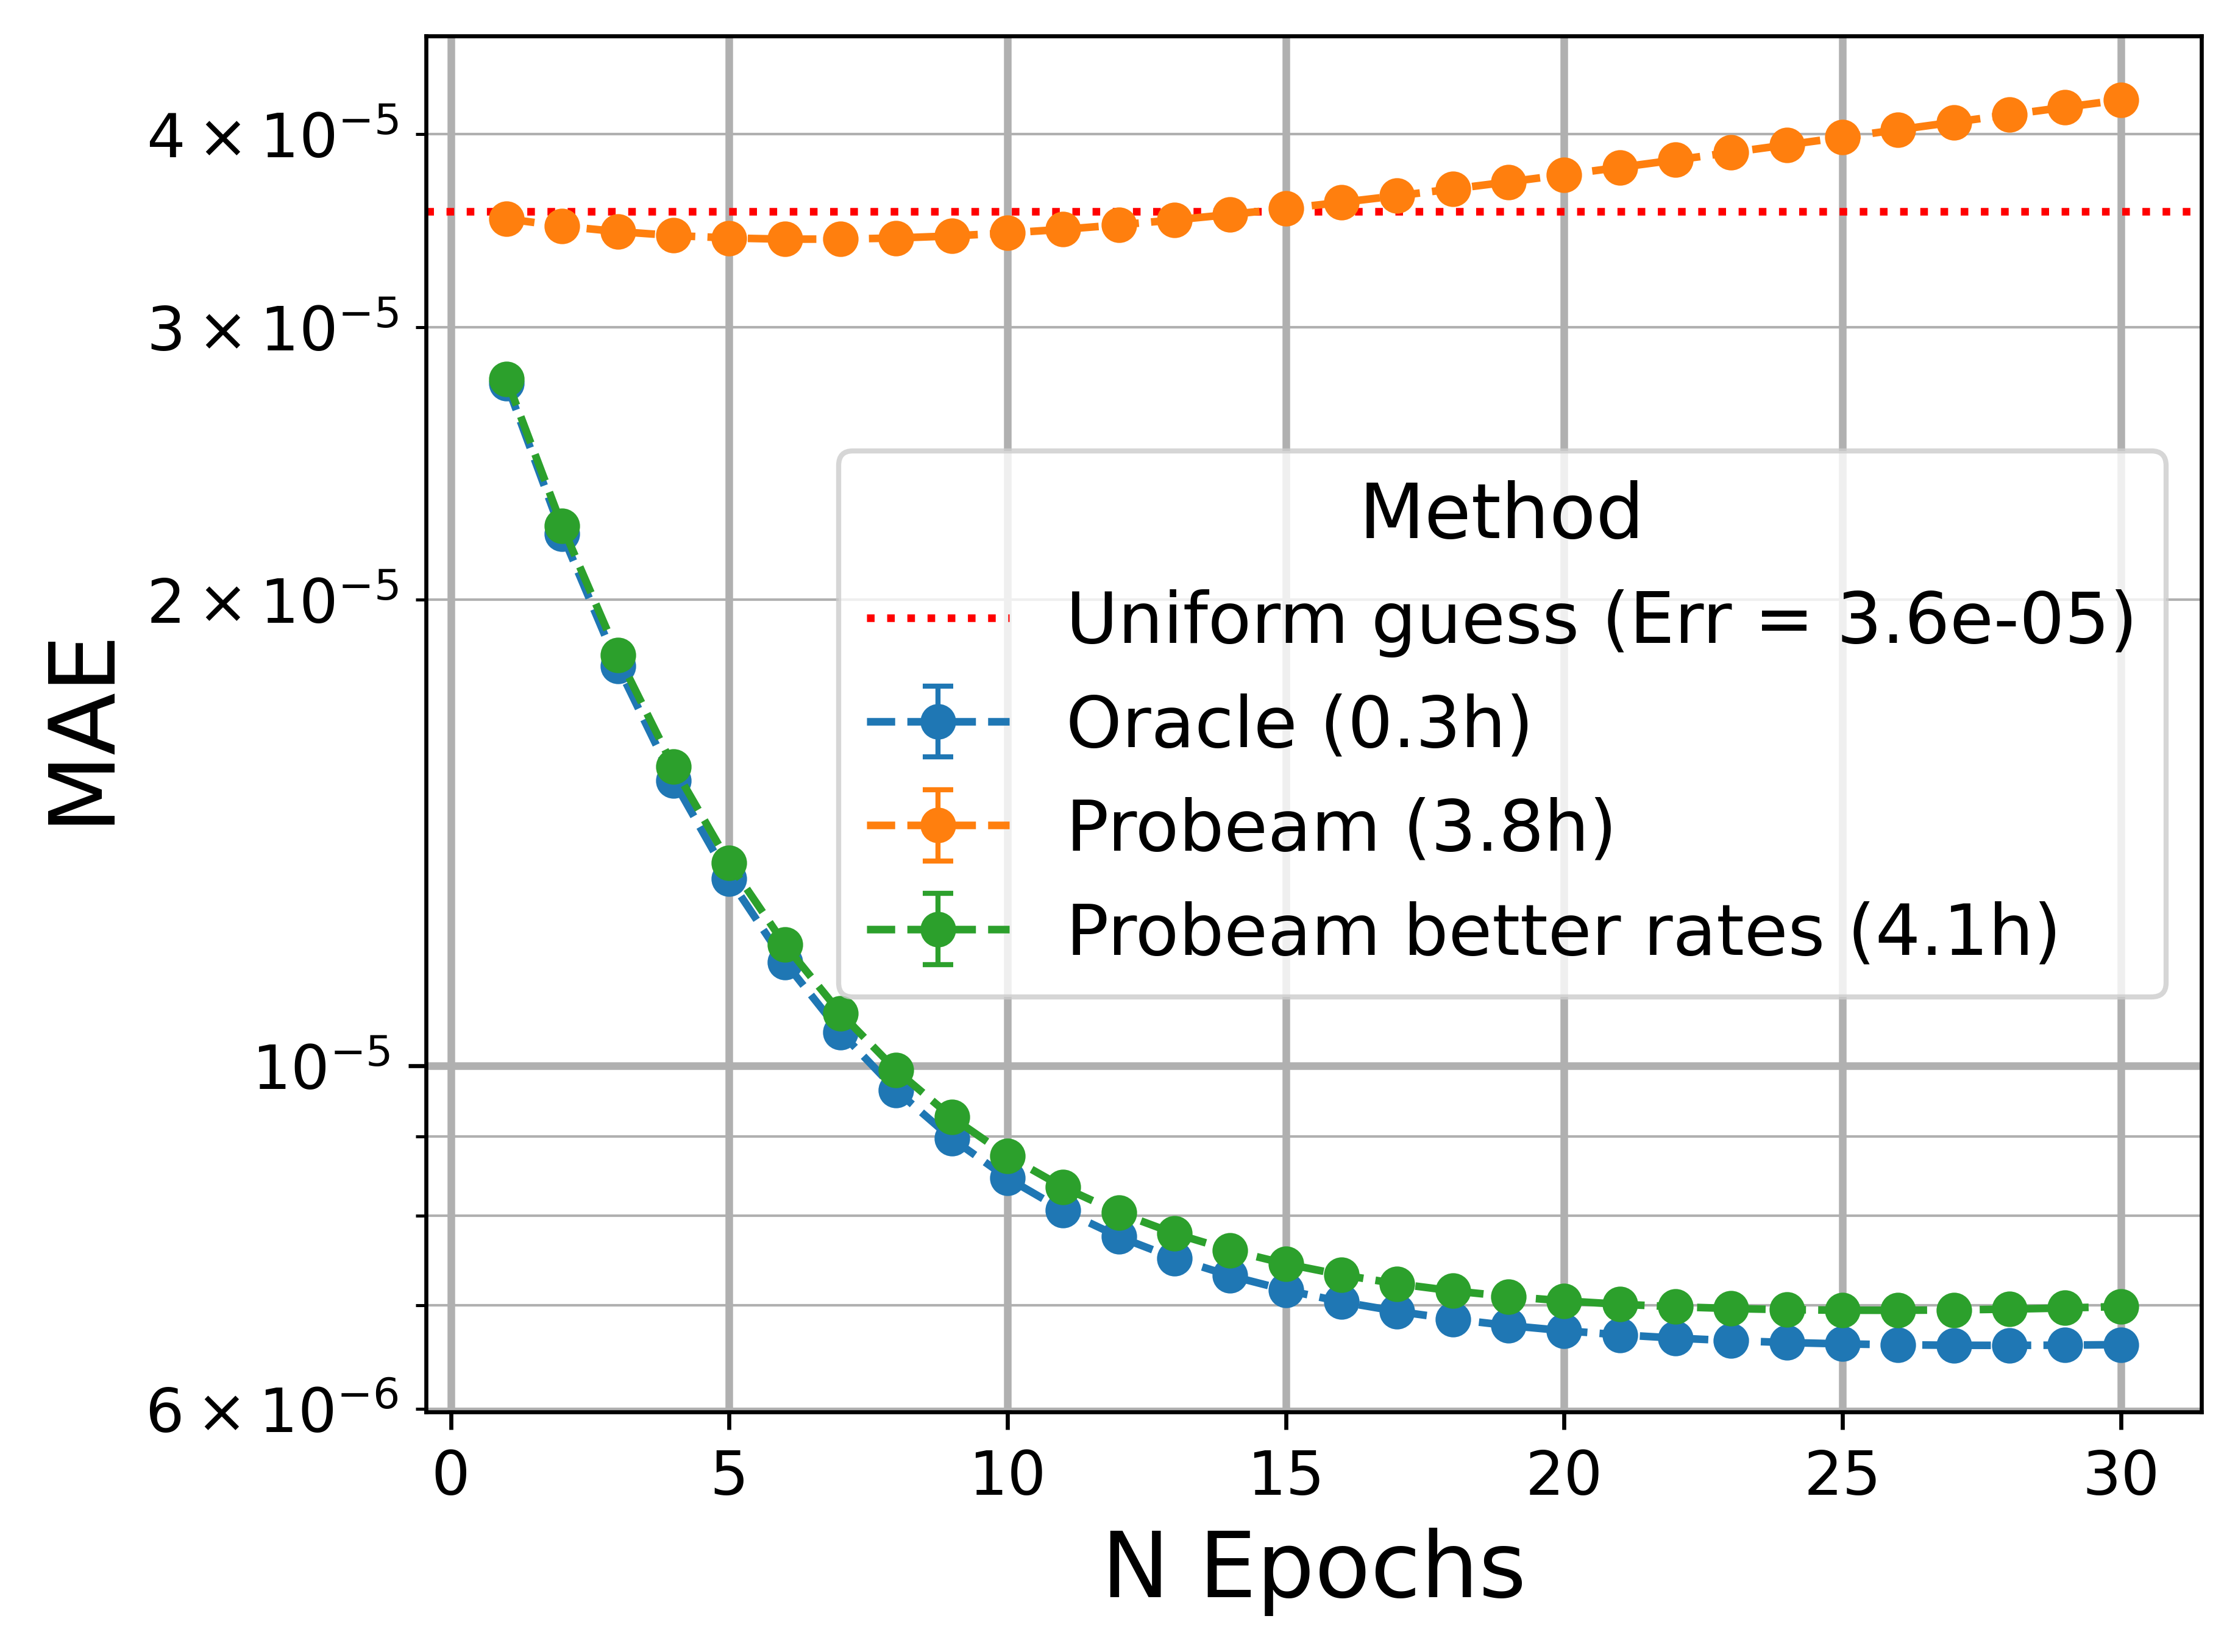

In [6]:
plot_comparison_error(path_probeam,path_probeam_better_config,path_oracle)

In [10]:
dataset_classifier_path="/home/jkipen/raid_storage/ProtInfGPU/data/20642_Prot/binary/ProbeamBetterConfigW100/"
def get_PhatYs(path_to_exp):
    n_crossval=int(ret_config(path_to_exp+"/RunConfig.txt","NcrossVal"));
    n_prot=int(ret_config(path_to_exp+"/RunConfig.txt","Nprot"));
    PhatYsConcatenated=np.fromfile(path_to_exp+"/PhatYs.bin", dtype=np.float32);
    PhatYsConcatenated=PhatYsConcatenated.reshape( n_crossval,n_prot);
    return PhatYsConcatenated;
def get_truePIs(ds_classifier_path,n_datasets=10):
    crossvalPath=ds_classifier_path+"CrossVal/";
    PYs_list=[];
    for i in range(n_datasets):
        PYs_list.append(np.fromfile(crossvalPath+"TrueProtDist"+str(i)+".bin", dtype=np.float32))
    PYs = np.column_stack(PYs_list).T 
    return PYs;

def plot_est_per_protein_axis_broken(path_probeam_better,path_oracle,dataset_classifier_path,n_ds_cv=0, log_x=False):
    #Protein Gene indicators
    df=pd.read_csv("/home/jkipen/raid_storage/ProtInfGPU/data/20642_Prot/binary/Probeam/protein_descriptions.csv")
    descriptions=df["Description"].to_list()
    prot_gen_gene = [desc.split('GN=')[1].split()[0]  for desc in descriptions]
    
    #From https://matplotlib.org/stable/gallery/subplots_axes_and_figures/broken_axis.html
    AllPhatYs_pb=get_PhatYs(path_probeam_better);
    AllPhatYs_o=get_PhatYs(path_oracle);
    AlltruePIs=get_truePIs(dataset_classifier_path);
    # n_ds_cv is Which crossval are we plotting.
    n_prot=np.shape(AlltruePIs)[1];

    PY=AlltruePIs[n_ds_cv,:];
    PhatY_pb=AllPhatYs_pb[n_ds_cv,:];
    PhatY_o=AllPhatYs_o[n_ds_cv,:];
    prot_indexes=np.argsort(PY) #We want the probs ordered, with higher on the top

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,dpi=600)
    fig.subplots_adjust(hspace=0.05)  # adjust space between Axes
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    ax1.scatter(PY[prot_indexes], np.arange(n_prot), color='black', marker='x',label="True")
    ax1.scatter(PhatY_o[prot_indexes], np.arange(n_prot),color=colors[0], marker='|',label="Oracle est ")
    ax1.scatter(PhatY_pb[prot_indexes], np.arange(n_prot), color=colors[1], marker='|',label="Probeam better rates est")
    ax1.axvline(x=1/n_prot, color='red', linestyle='--', linewidth=1,label="Uniform Guess")

    ax2.axvline(x=1/n_prot, color='red', linestyle='--', linewidth=1,label="Uniform Guess")
    ax2.scatter(PY[prot_indexes], np.arange(n_prot), color='black', marker='x',label="True")
    ax2.scatter(PhatY_o[prot_indexes], np.arange(n_prot), color=colors[0], marker='|',label="Oracle est")
    ax2.scatter(PhatY_pb[prot_indexes], np.arange(n_prot),  color=colors[1], marker='|',label="Probeam better rates est")



    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                  linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

    ax1.set_yticks(np.arange(n_prot,dtype=np.uint32)) 
    protein_labels = [prot_gen_gene[idx] for idx in prot_indexes]
    ax1.set_yticklabels(protein_labels)
    ax2.set_yticks(np.arange(n_prot,dtype=np.uint32))  
    ax2.set_yticklabels(protein_labels)

    ax1.set_ylim(n_prot-7.5, n_prot-0.5)  # outliers only
    ax2.set_ylim(-0.5, 7.5)  # most of the data

    max_prob=np.max(PY);
    
    
    
    if log_x:
        ax1.set_xscale('log')
        ax2.set_xscale('log')
        min_prob=np.min(PY);
        ax1.set_xlim(min_prob*0.5, max_prob*2)  # outliers only
        ax2.set_xlim(min_prob*0.5, max_prob*2)  # most of the data
    else:
        ax1.set_xlim(-max_prob*0.05, max_prob*1.1)  # outliers only
        ax2.set_xlim(-max_prob*0.05, max_prob*1.1)  # most of the data
    
    ax1.grid()
    ax2.grid()


    ax2.legend(title="Method")
    
    fig.supylabel("Protein's gene name", x=-0.04, fontsize=18)
    plt.xlabel("Relative abundance")
    plt.tight_layout()
    plt.savefig(f"../results/20642_Prot/ComparisonAbundances.png", bbox_inches='tight')
    

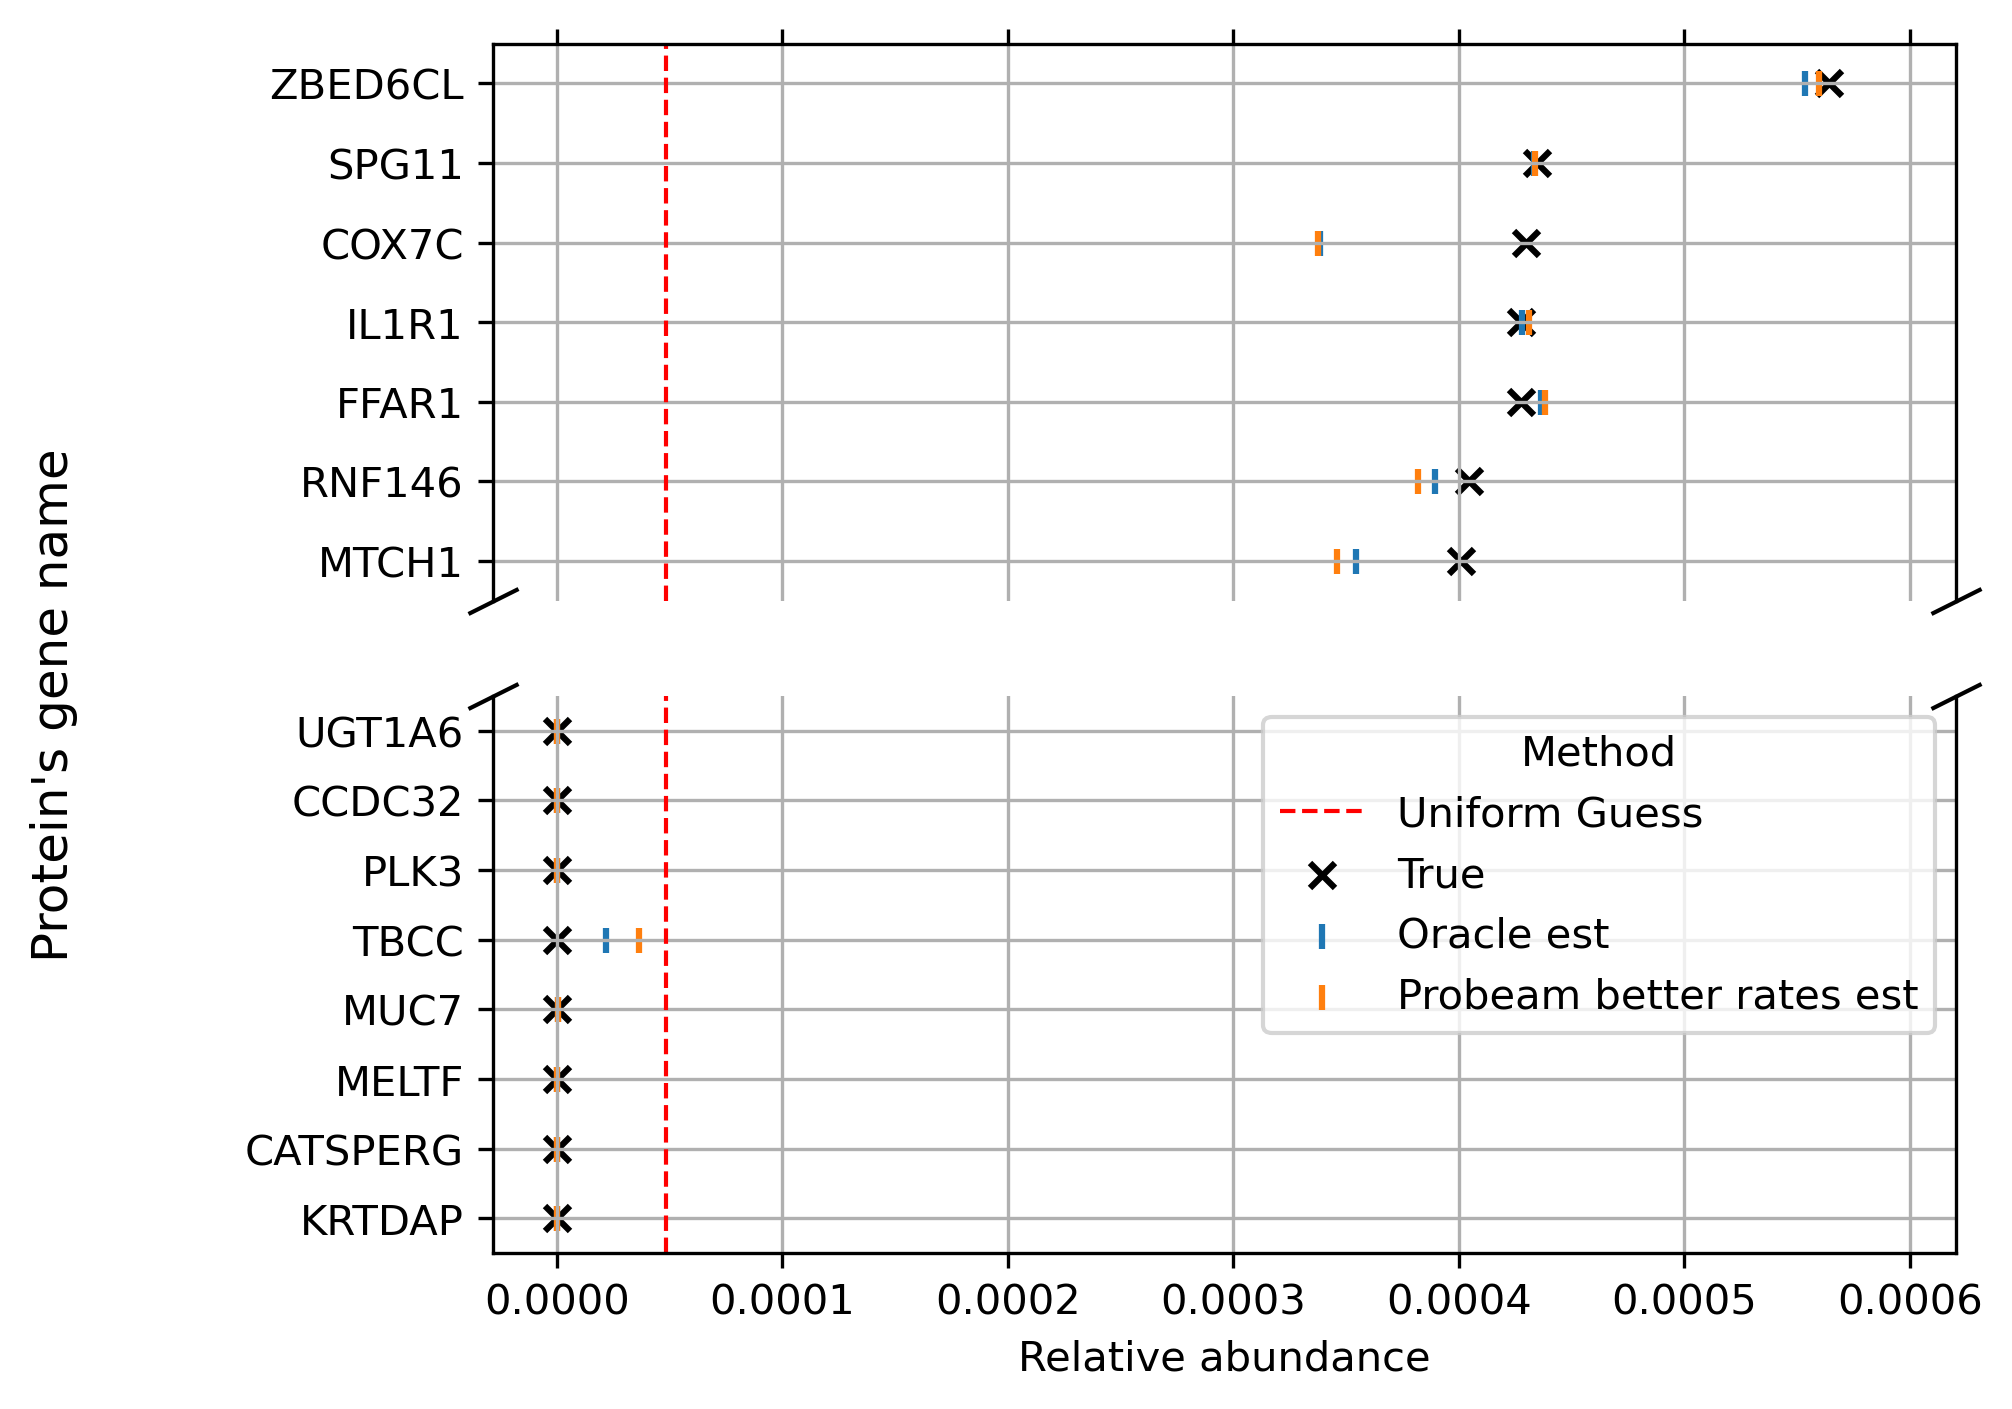

In [6]:
plot_est_per_protein_axis_broken(path_probeam_better_config,path_oracle,dataset_classifier_path,n_ds_cv=1)
#This one (number 1) illustrates well how it works

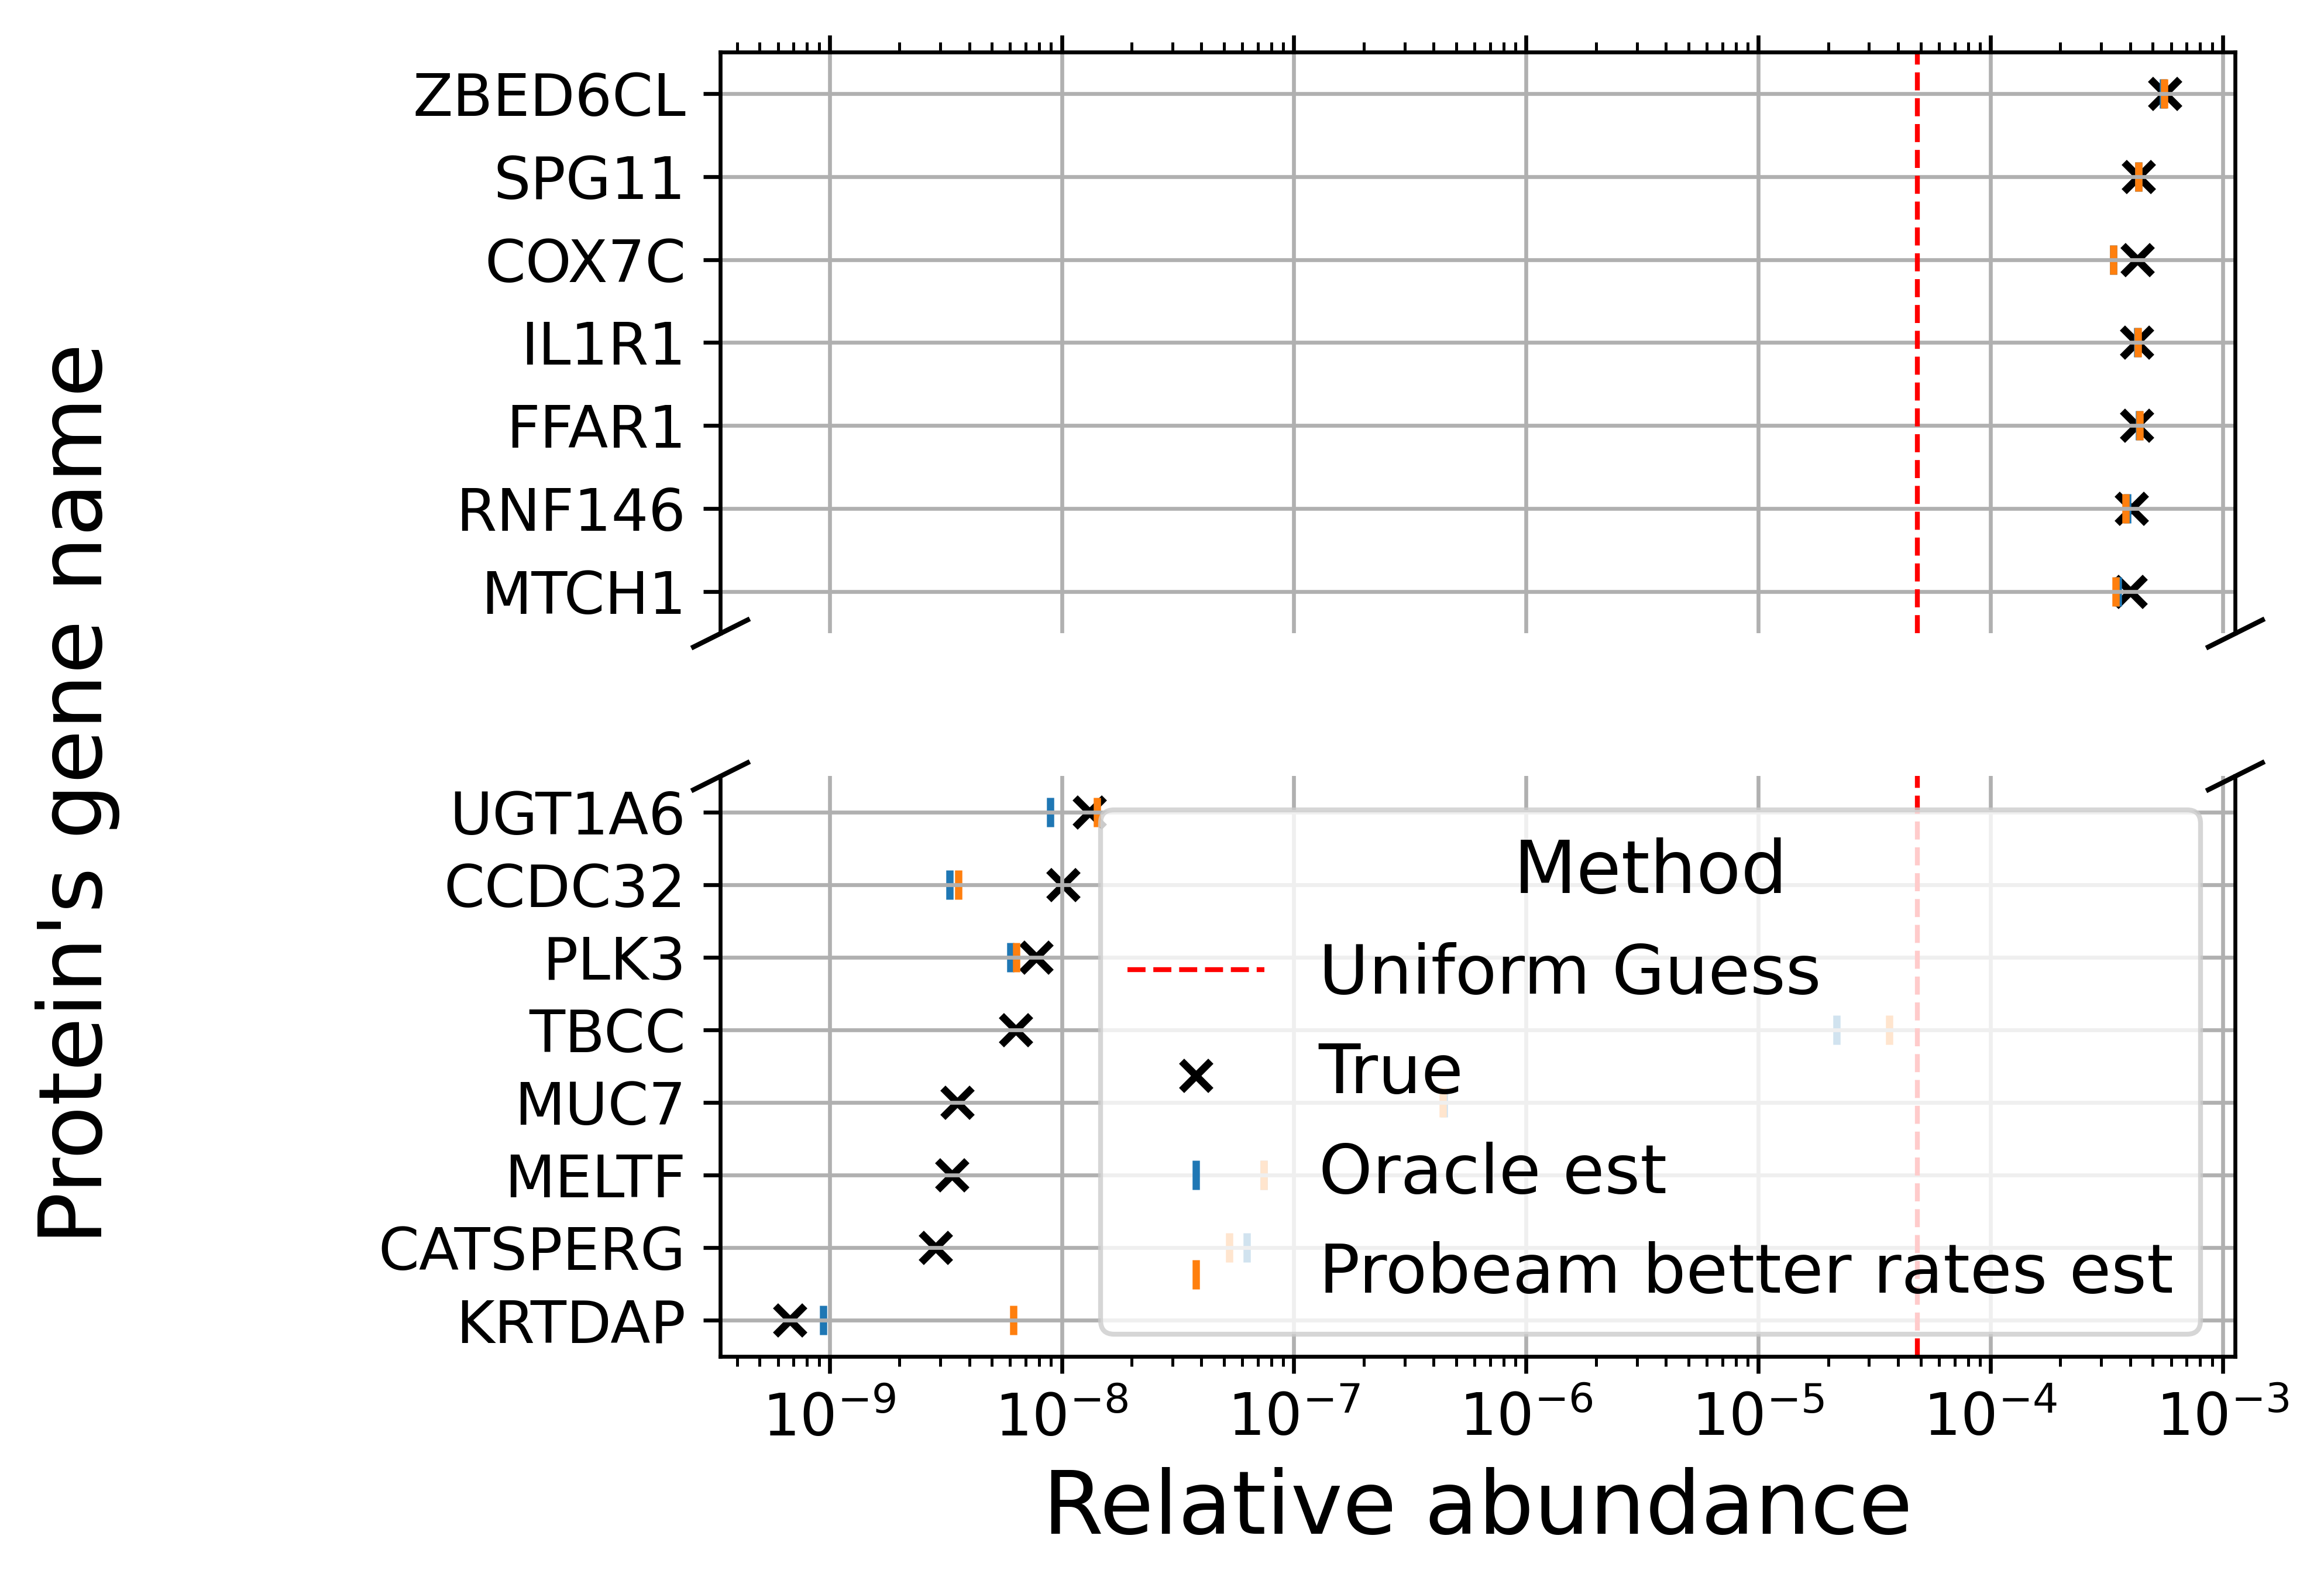

In [11]:
plot_est_per_protein_axis_broken(path_probeam_better_config,path_oracle,dataset_classifier_path,n_ds_cv=1,log_x=True)

# Calculate number of proteins

Here we estimate which was the number of proteins for the datasets, as per request of Marcotte to show. 

In [6]:
AlltruePIs=get_truePIs(dataset_classifier_path);
expNFluExpGenByI=np.fromfile("/home/jkipen/raid_storage/ProtInfGPU/data/20642_Prot/binary/Common/expNFluExpGenByI.bin", dtype=np.float32);
expNFluExpGenByI=expNFluExpGenByI.reshape(-1,1)
sums=AlltruePIs @ expNFluExpGenByI;
NreadsPerExp=10e6;
print("The estimated count of proteins per runned experiment was " + str(np.mean(NreadsPerExp/sums)))

The estimated count of proteins per runned experiment was 296853.06


In [10]:
np.multiply(AlltruePIs,expNFluExpGenByI)

ValueError: operands could not be broadcast together with shapes (10,20642) (20642,1) 

In [18]:
reads_of_prots_in_exp = AlltruePIs * expNFluExpGenByI.reshape(1, -1) * NreadsPerExp
np.mean(np.sum(reads_of_prots_in_exp>1,axis=1)/20642)

0.9998498207538029

99.98% of the proteins were present in avg in the 10 datasets, so they are present!